Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score,fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier

In [8]:
import xgboost as xgb
import shap

## data

In [9]:
csv_path_output = '../data/output/'
file_name = 'homecredit_agg.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')

In [10]:
df.shape

(356251, 798)

In [11]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Explo

## Valeurs manquantes

In [12]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [13]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [14]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Séparation du jeu de données en jeu de  training/validation et jeu de test
train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
print(train_df.shape, test_df.shape)
train_df["TARGET"].value_counts()/train_df.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.2536
Your selected dataframe has 798 columns.
There are 617 columns that have missing values.
(307507, 798) (48744, 798)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.2589
Taux de valeurs manquantes dans jeu de test avant imputation : 0.22


# Typage

In [15]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.dtypes

index                                 int64
SK_ID_CURR                            int64
TARGET                              float64
CODE_GENDER                           int64
FLAG_OWN_CAR                          int64
                                     ...   
CC_NAME_CONTRACT_STATUS_nan_MAX     float64
CC_NAME_CONTRACT_STATUS_nan_MEAN    float64
CC_NAME_CONTRACT_STATUS_nan_SUM     float64
CC_NAME_CONTRACT_STATUS_nan_VAR     float64
CC_COUNT                            float64
Length: 798, dtype: object

In [17]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
df2 = df.copy()
df2 = df2.convert_dtypes()

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df2_memory_usage_gb = df2.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df2_memory_usage_gb} Gb')
del df2
gc.collect()

Dtypes initiaux :
float64    622
int64      176
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.1181129962205887 Gb

Dtypes après conversion :
float64    622
int64      176
dtype: int64

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.382877105847001 Gb


0

In [18]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

Dtypes initiaux :
float64    622
int64      176
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.1181129962205887 Gb

Dtypes après conversion :
float32    622
int8       172
int32        2
int16        2
dtype: int64

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float32(622), int16(2), int32(2), int8(172)
memory usage: 907.8 MB
None
0.8865285664796829 Gb


In [19]:
df['TARGET'].value_counts(dropna=False)

0.0    282682
NaN     48744
1.0     24825
Name: TARGET, dtype: int64

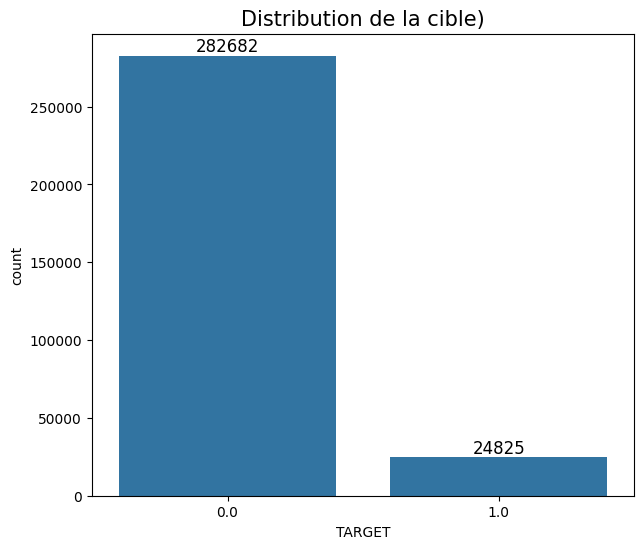

In [20]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [21]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (307507, 798)
Dimensions de X_test : (48744, 798)


In [22]:
X_train['TARGET'].value_counts(dropna=False)

0.0    282682
1.0     24825
Name: TARGET, dtype: int64

In [23]:
# Compter le nombre d'éléments ayant TARGET à 1
count_target_1 = df['TARGET'].value_counts()[1]

# Sélectionner aléatoirement un nombre similaire d'éléments ayant TARGET à 0
df_target_0 = df[df['TARGET'] == 0]
df_target_0_sampled = df_target_0.sample(n=count_target_1, random_state=42)

# Sélectionner tous les éléments ayant TARGET à 1
df_target_1 = df[df['TARGET'] == 1]

# Combiner les deux ensembles pour former le nouvel ensemble X_train
X_train = pd.concat([df_target_0_sampled, df_target_1])

# Afficher les dimensions du nouvel ensemble X_train
print("Dimensions de X_train :", X_train.shape)
print("Décompte des valeurs de TARGET dans X_train :")
print(X_train['TARGET'].value_counts(dropna=False))

Dimensions de X_train : (49650, 798)
Décompte des valeurs de TARGET dans X_train :
0.0    24825
1.0    24825
Name: TARGET, dtype: int64


In [24]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
10203748


In [25]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                               Feature  Missing Percentage
0                        REFUSED_RATE_DOWN_PAYMENT_MIN           84.080564
1                         REFUSED_AMT_DOWN_PAYMENT_MAX           84.080564
2                       REFUSED_RATE_DOWN_PAYMENT_MEAN           84.080564
3                         REFUSED_AMT_DOWN_PAYMENT_MIN           84.080564
4                        REFUSED_RATE_DOWN_PAYMENT_MAX           84.080564
5                        REFUSED_AMT_DOWN_PAYMENT_MEAN           84.080564
6                          REFUSED_APP_CREDIT_PERC_VAR           81.079557
7                              ACTIVE_AMT_ANNUITY_MEAN           79.401813
8                               ACTIVE_AMT_ANNUITY_MAX           79.401813
9                              CLOSED_AMT_ANNUITY_MEAN           79.033233
10                              CLOSED_AMT_ANNUITY_MAX           79.033233
11                          CC_AMT_PAYMENT_CURRENT_V

In [26]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [27]:
missing_values_count(df)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                       184            23.057644
0-20%                    325            40.726817
20-40%                    44             5.513784
40-60%                    33             4.135338
60-100%                  212            26.566416


# Modélisations + feature importance

In [28]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [29]:
X.head()

,index,SK_ID_CURR,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
150486,150489,274455,1,1,0,2,202500.0,270000.0,13500.0,270000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136656,136659,258502,0,1,0,0,157500.0,1125000.0,33025.5,1125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0
136808,136811,258682,1,1,0,0,135000.0,1113840.0,44302.5,900000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18793,18793,121915,1,0,0,2,94500.0,177903.0,12510.0,148500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188846,188849,318940,1,0,0,2,90000.0,1100709.0,46764.0,1012500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
y.head()

150486    0.0
136656    0.0
136808    0.0
18793     0.0
188846    0.0
Name: TARGET, dtype: float32

In [31]:
X = X.drop(columns=['index', 'SK_ID_CURR'])
X.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
150486,1,1,0,2,202500.0,270000.0,13500.0,270000.0,0.018029,-15318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136656,0,1,0,0,157500.0,1125000.0,33025.5,1125000.0,0.018850,-10341,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0
136808,1,1,0,0,135000.0,1113840.0,44302.5,900000.0,0.035792,-19278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18793,1,0,0,2,94500.0,177903.0,12510.0,148500.0,0.025164,-14666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188846,1,0,0,2,90000.0,1100709.0,46764.0,1012500.0,0.010276,-11561,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## XGBoost

### Model

In [33]:
# Convertir les données en DMatrix pour XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Définir les paramètres du modèle XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle XGBoost
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

In [34]:
# Prédire les probabilités pour la classe positive
y_pred_proba = xgb_model.predict(dtest)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_roc

0.7727116412829078

### Feature Importance (SHAPE)

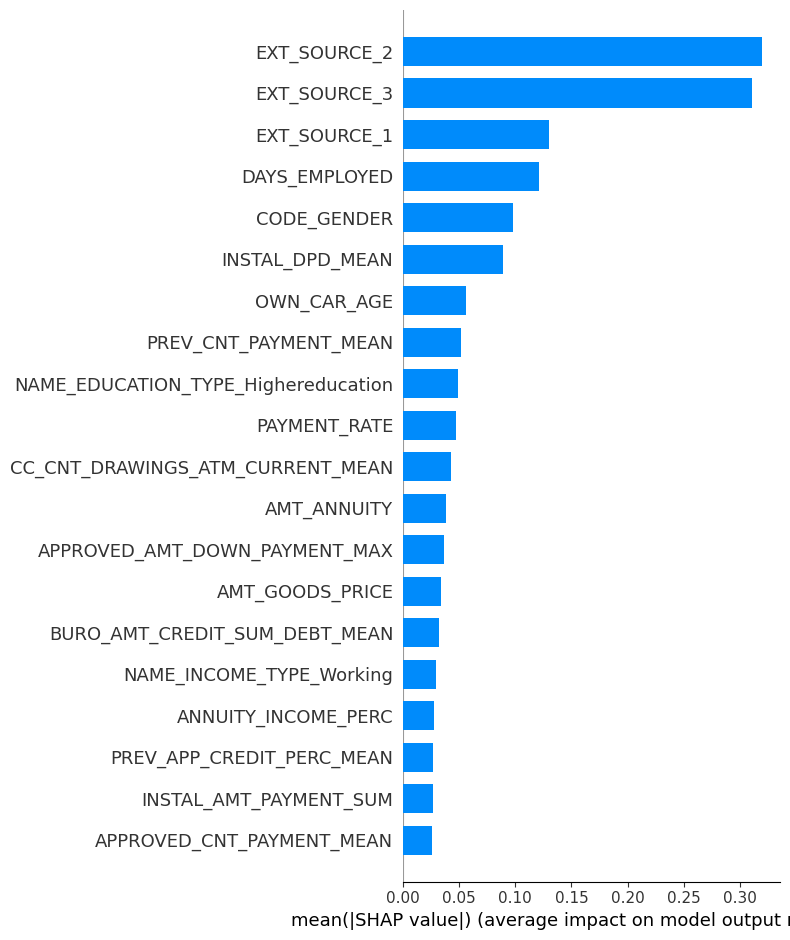

In [35]:
# Calculer les valeurs SHAP
model1_explainer = shap.TreeExplainer(xgb_model)
model1_shap_values = model1_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model1_shap_values, X_test, plot_type='bar')

## LightGBM

### Model

In [36]:
# Convertir les données en Dataset pour LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)

# Définir les paramètres du modèle LightGBM
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle LightGBM
LGBM_model = lgb.train(params, dtrain, num_boost_round=100)

[LightGBM] [Info] Number of positive: 17366, number of negative: 17389
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91836
[LightGBM] [Info] Number of data points in the train set: 34755, number of used features: 771
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499669 -> initscore=-0.001324
[LightGBM] [Info] Start training from score -0.001324
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [37]:
# Prédire les probabilités pour la classe positive
y_pred_proba = LGBM_model.predict(X_test)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc_roc}")

AUC-ROC: 0.772433214067997


### Feature Importance (SHAP)

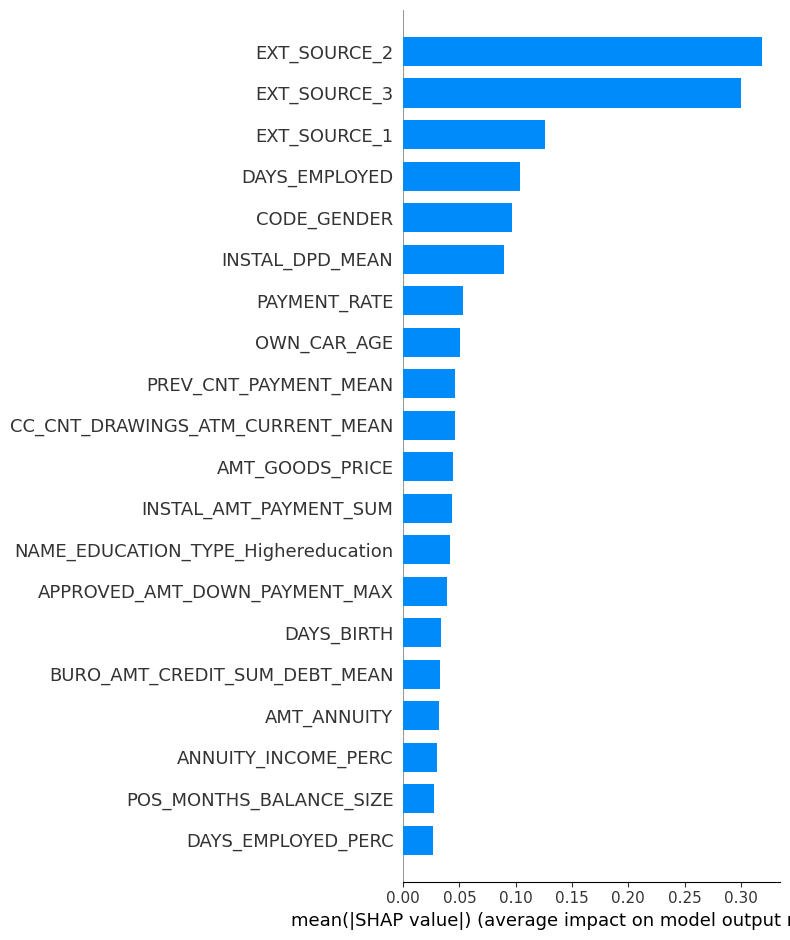

In [38]:
# Calculer les valeurs SHAP
model2_explainer = shap.TreeExplainer(LGBM_model)
model2_shap_values = model2_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model2_shap_values, X_test, plot_type='bar')

## Random Forest

### Model

In [39]:
# Initialiser le modèle Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
# Prédire les probabilités pour la classe positive
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculer le score ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc}")

ROC-AUC Score: 0.7427409699832277


### Feature Importance (most important features)

In [41]:
# Obtenir l'importance des caractéristiques
feature_importances = model.feature_importances_

# Créer un DataFrame pour afficher les importances des caractéristiques
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Afficher l'importance des caractéristiques
print("Importance des caractéristiques :")
print(feature_importance_df)

Importance des caractéristiques :
                                               Feature    Importance
31                                        EXT_SOURCE_2  2.502354e-02
32                                        EXT_SOURCE_3  2.140939e-02
30                                        EXT_SOURCE_1  1.104577e-02
10                                       DAYS_EMPLOYED  1.007418e-02
240                                 DAYS_EMPLOYED_PERC  9.550648e-03
9                                           DAYS_BIRTH  7.898205e-03
247                              BURO_DAYS_CREDIT_MEAN  5.682210e-03
246                               BURO_DAYS_CREDIT_MAX  5.503951e-03
244                                       PAYMENT_RATE  5.315743e-03
308                             ACTIVE_DAYS_CREDIT_MAX  5.141336e-03
11                                   DAYS_REGISTRATION  5.123488e-03
251                      BURO_DAYS_CREDIT_ENDDATE_MEAN  5.032983e-03
243                                ANNUITY_INCOME_PERC  5.017847e-03


In [42]:
feature_importance_df.shape

(795, 2)

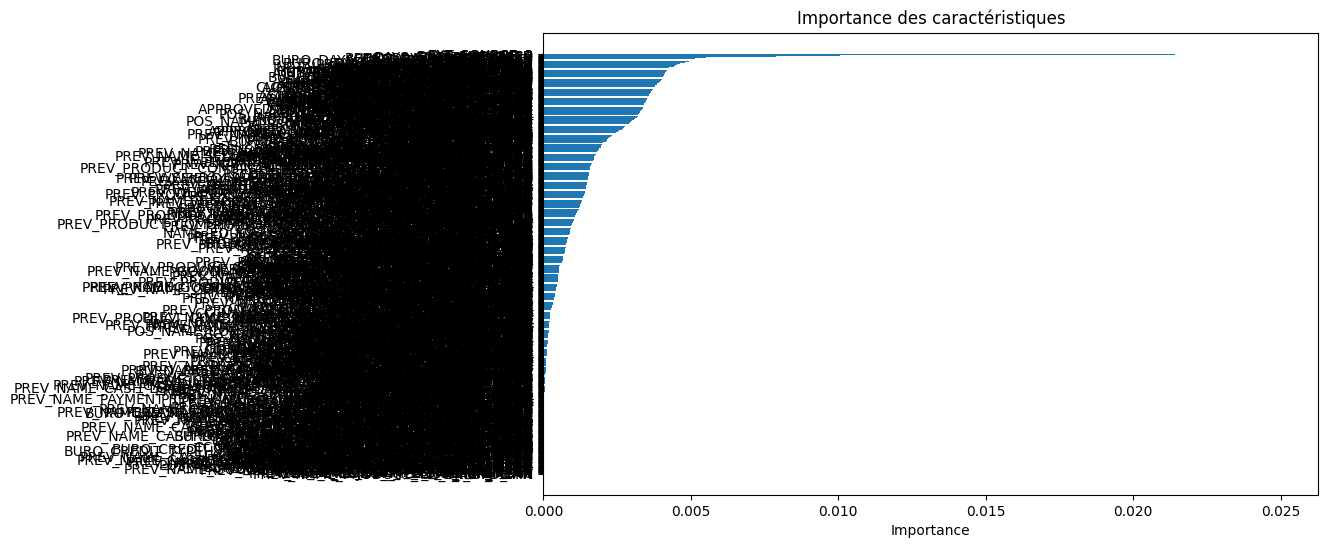

In [43]:
# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Importance des caractéristiques')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

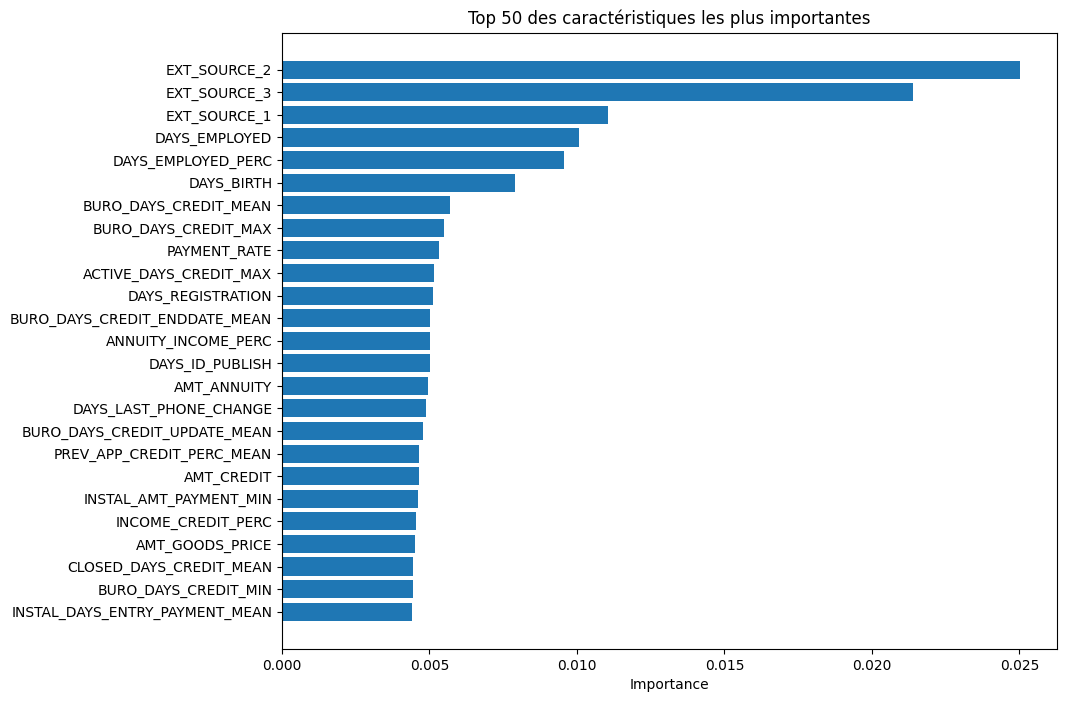

In [44]:
# Sélectionner le top des caractéristiques les plus importantes
top_features = feature_importance_df.head(25)

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 50 des caractéristiques les plus importantes')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

## Consolidation / Sélection Features

In [45]:
# Calculer l'importance moyenne absolue des valeurs SHAP pour chaque modèle
shap_importance_model1 = np.mean(np.abs(model1_shap_values), axis=0)
shap_importance_model2 = np.mean(np.abs(model2_shap_values), axis=0)

# Créer des DataFrames pour les importances SHAP
shap_importance_df_model1 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model1_shap_values.shape[1])],
    'Importance': shap_importance_model1
})

shap_importance_df_model2 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model2_shap_values.shape[1])],
    'Importance': shap_importance_model2
})

# Normaliser les importances pour chaque modèle
def normalize_importance(df):
    df['Importance'] = (df['Importance'] - df['Importance'].min()) / (df['Importance'].max() - df['Importance'].min())
    return df

shap_importance_df_model1 = normalize_importance(shap_importance_df_model1)
shap_importance_df_model2 = normalize_importance(shap_importance_df_model2)
feature_importance_df = normalize_importance(feature_importance_df)

# Combiner les importances normalisées
combined_importance = pd.DataFrame({
    'Feature': feature_importance_df['Feature'],
    'Combined_Importance': (shap_importance_df_model1['Importance'] +
                             shap_importance_df_model2['Importance'] +
                             feature_importance_df['Importance']) / 3,
    'XGBoost_Importance': shap_importance_df_model1['Importance'],
    'Light_GBM_Importance': shap_importance_df_model2['Importance'],
    'RandomForest_Importance': feature_importance_df['Importance']
})

# Trier les caractéristiques par leur importance combinée
combined_importance = combined_importance.sort_values(by='Combined_Importance', ascending=False)

# Sélectionner les 40 caractéristiques les plus importantes
top_40_features = combined_importance.head(40)

# Afficher les 40 caractéristiques les plus importantes
print("Top 40 des caractéristiques les plus importantes :")
print(top_40_features)

Top 40 des caractéristiques les plus importantes :
                                 Feature  Combined_Importance  \
31                          EXT_SOURCE_2             1.000000   
32                          EXT_SOURCE_3             0.923031   
30                          EXT_SOURCE_1             0.414575   
10                         DAYS_EMPLOYED             0.368594   
630                      INSTAL_DPD_MEAN             0.242336   
0                            CODE_GENDER             0.224786   
244                         PAYMENT_RATE             0.175283   
240                   DAYS_EMPLOYED_PERC             0.166470   
9                             DAYS_BIRTH             0.165940   
13                           OWN_CAR_AGE             0.147618   
389                PREV_CNT_PAYMENT_MEAN             0.145783   
7                        AMT_GOODS_PRICE             0.141709   
6                            AMT_ANNUITY             0.139301   
243                  ANNUITY_INCOME_PER

## Réduction DF

In [46]:
top_40_features_target = top_40_features.copy()
top_40_features_target.loc[-1] = 'TARGET'

In [47]:
# Réduire dataframe
df_reduced = df[top_40_features_target['Feature']]
df_reduced.shape

(356251, 41)

In [58]:
def check_missing(df):
    # Calculer le nombre total de valeurs manquantes
    total_missing = df.isna().sum().sum()
    
    # Calculer le pourcentage de valeurs manquantes
    total_cells = df.size
    percentage_missing = (total_missing / total_cells) * 100
    
    # Afficher le total et le pourcentage de valeurs manquantes
    print(f"Total de cellules dans df_reduced: {total_cells}")
    print(f"Total de valeurs manquantes dans df_reduced: {total_missing}")
    print(f"Pourcentage de valeurs manquantes dans df_reduced: {percentage_missing:.2f}%")

In [59]:
check_missing(df_reduced)

Total de cellules dans df_reduced: 14606291
Total de valeurs manquantes dans df_reduced: 1962189
Pourcentage de valeurs manquantes dans df_reduced: 13.43%


In [49]:
missing_values_count(df_reduced)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                         6            14.634146
0-20%                     28            68.292683
20-40%                     3             7.317073
40-60%                     2             4.878049
60-100%                    2             4.878049


In [50]:
missing_values = df_reduced.isna().sum()
missing_percentage = (missing_values / len(df_reduced)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Afficher les valeurs manquantes et les pourcentages
print("Valeurs manquantes et pourcentages dans df_reduced :")
print(missing_info)

Valeurs manquantes et pourcentages dans df_reduced :
                                     Missing Values  Missing Percentage (%)
EXT_SOURCE_2                                    668                0.187508
EXT_SOURCE_3                                  69633               19.546050
EXT_SOURCE_1                                 193908               54.430163
DAYS_EMPLOYED                                 64648               18.146756
INSTAL_DPD_MEAN                               16668                4.678724
CODE_GENDER                                       0                0.000000
PAYMENT_RATE                                     36                0.010105
DAYS_EMPLOYED_PERC                            64648               18.146756
DAYS_BIRTH                                        0                0.000000
OWN_CAR_AGE                                  235239               66.031815
PREV_CNT_PAYMENT_MEAN                         17876                5.017810
AMT_GOODS_PRICE                    

Text(0.5, 1.0, "Heatmap des corrélations - 'application_train'")

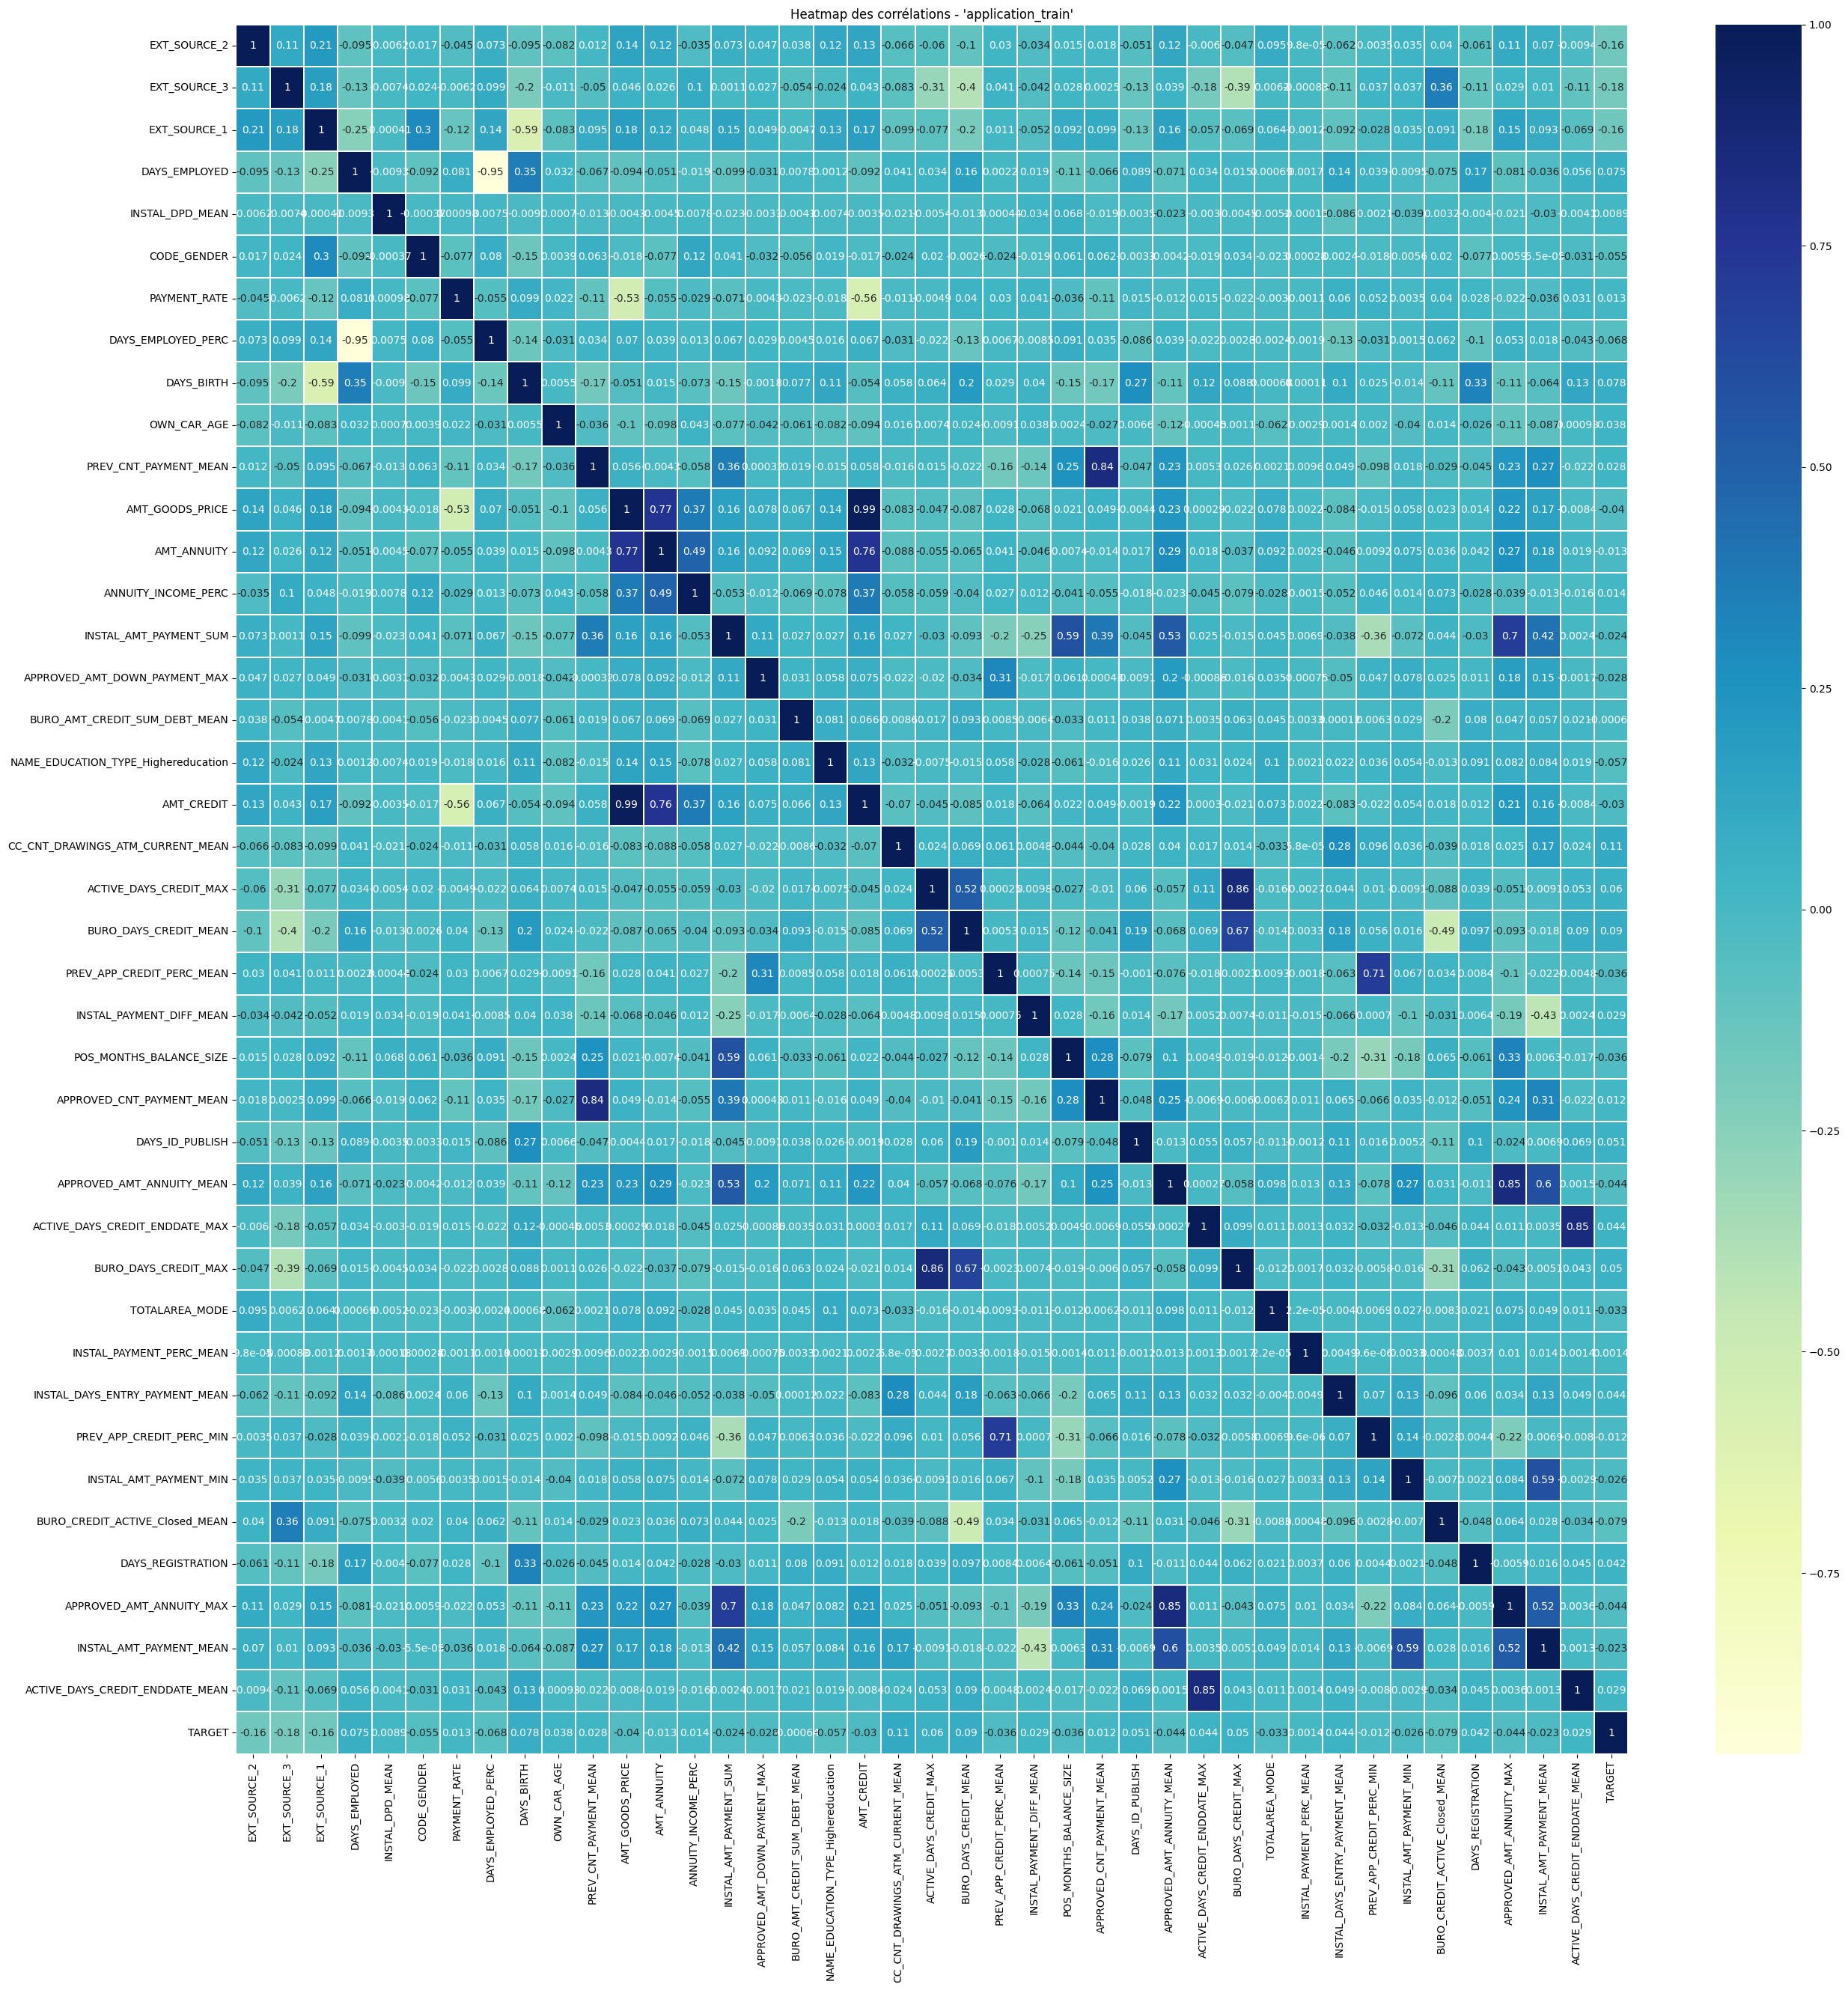

In [51]:
# Affichage de la heatmap des corrélations
plt.figure(figsize=(30,30))
sns.heatmap(df_reduced.corr() , annot=True, linewidths=.2, cmap="YlGnBu")
plt.title("Heatmap des corrélations - 'application_train'")

### Données manquantes

In [52]:
# Sauvegarder la forme initiale
total_rows_initial, total_cols_initial = df_reduced.shape

# Seuil pour supprimer les colonnes (par exemple, 50% de valeurs manquantes)
threshold = 0.5

# Supprimer les colonnes avec plus de 50% de valeurs manquantes
df_cleaned = df_reduced.dropna(thresh=len(df_reduced) * (1 - threshold), axis=1)

# Supprimer les lignes avec des valeurs manquantes
df_cleaned = df_cleaned.dropna()

# Sauvegarder la forme finale
total_rows_final, total_cols_final = df_cleaned.shape

# Calculer les différences et pourcentages
delta_rows = total_rows_initial - total_rows_final
delta_cols = total_cols_initial - total_cols_final

percentage_rows_removed = (delta_rows / total_rows_initial) * 100
percentage_cols_removed = (delta_cols / total_cols_initial) * 100

print(f"Forme initiale du DataFrame: {total_rows_initial} lignes, {total_cols_initial} colonnes")
print(f"Forme finale du DataFrame: {total_rows_final} lignes, {total_cols_final} colonnes")
print(f"Lignes supprimées: {delta_rows} ({percentage_rows_removed:.2f}%)")
print(f"Colonnes supprimées: {delta_cols} ({percentage_cols_removed:.2f}%)")

Forme initiale du DataFrame: 356251 lignes, 41 colonnes
Forme finale du DataFrame: 74878 lignes, 38 colonnes
Lignes supprimées: 281373 (78.98%)
Colonnes supprimées: 3 (7.32%)


In [60]:
check_missing(df_cleaned)

Total de cellules dans df_reduced: 2845364
Total de valeurs manquantes dans df_reduced: 0
Pourcentage de valeurs manquantes dans df_reduced: 0.00%


## Export

In [55]:
df_cleaned.shape

(74878, 38)

In [56]:
df_cleaned.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,1.000000,-315.421051,1.000000,9251.775391,0.750000,-3648.0,9251.775391,11559.247070,780.00,1.0
12,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.837838,-1297.581055,0.909881,3.960000,0.428571,-311.0,14480.459961,8391.646484,381.75,0.0
18,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,1.000000,-142.428574,0.863260,6765.975098,0.000000,-8751.0,6765.975098,6765.975098,940.00,0.0
22,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,1.000000,-1105.875000,0.906651,23531.175781,0.333333,-114.0,42778.843750,119294.593750,899.00,0.0
25,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,1.000000,-730.666687,0.949873,9035.684570,0.666667,-2419.0,9035.684570,11820.644531,1409.00,0.0


In [57]:
output_name = 'df_reduced.csv'

df_cleaned.to_csv(csv_path_output + output_name, encoding='ISO-8859-1')

print('Export terminé')

Export terminé
